<a href="https://colab.research.google.com/github/marcelalozano27-ship-it/Predicting-CA-Poverty--ML-Project/blob/main/MLFinalProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting Risk of Poverty in CA

Aziza, Fong, Marcela

###  Primary Research Question
Which individuals in California are most vulnerable to poverty based on their education level, employment conditions, demographic characteristics, and access to health insurance?

#### Supporting Sub Questions
1. Education and Poverty Risk: How does education level affect the likelihood of experiencing poverty in California?
2. Employment Conditions and Poverty Risk: Which employment patterns are most associated with poverty risk?
3. Demographic Inequality and Poverty Risk: How do age, marital status, race, and nativity relate to poverty vulnerability?

### Why this topic?

Poverty remains a critical social and economic issue in California, affecting millions of individuals and contributing to inequality in health, education, and economic opportunity. Identifying populations that are most vulnerable to poverty is essential for policymakers, nonprofits, and government agencies to design targeted interventions and allocate resources effectively.

This project leverages machine learning to predict poverty risk based on key factors such as education, employment conditions, demographic characteristics, and access to health insurance. These variables were chosen because they represent structural determinants of economic stability and are commonly used in policy analysis.

In addition to prediction, the project aims to identify the most influential factors driving poverty risk. This allows for actionable insights, helping decision-makers prioritize areas such as education access, employment quality, and healthcare coverage to reduce poverty at scale.

### Literature Survey



In [1]:
#install duckdb
#!pip -q install duckdb

In [2]:
#download and unzip
!wget -nc https://www2.census.gov/programs-surveys/acs/data/pums/2024/5-Year/csv_pca.zip
!unzip -o csv_pca.zip

File ‘csv_pca.zip’ already there; not retrieving.

Archive:  csv_pca.zip
  inflating: psam_p06.csv            
  inflating: ACS2020_2024_PUMS_README.pdf  


In [3]:
import duckdb
import os
from google.colab import files
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [4]:
 cols = pd.read_csv("psam_p06.csv", nrows=0).columns.tolist()
 print(f"Total columns: {len(cols)}")
print(cols)

Total columns: 285
['RT', 'SERIALNO', 'DIVISION', 'SPORDER', 'PUMA', 'REGION', 'STATE', 'ADJINC', 'PWGTP', 'AGEP', 'CIT', 'CITWP', 'COW', 'DDRS', 'DEAR', 'DEYE', 'DOUT', 'DPHY', 'DRAT', 'DRATX', 'DREM', 'ENG', 'FER', 'GCL', 'GCM', 'GCR', 'HINS1', 'HINS2', 'HINS3', 'HINS4', 'HINS5', 'HINS6', 'HINS7', 'INTP', 'JWMNP', 'JWRIP', 'JWTRNS', 'LANX', 'MAR', 'MARHD', 'MARHM', 'MARHT', 'MARHW', 'MARHYP', 'MIG', 'MIL', 'MLPA', 'MLPB', 'MLPCD', 'MLPE', 'MLPFG', 'MLPHJ', 'MLPIK', 'NWAB', 'NWAV', 'NWLA', 'NWLK', 'NWRE', 'OIP', 'PAP', 'RELSHIPP', 'RETP', 'SCH', 'SCHG', 'SCHL', 'SEMP', 'SEX', 'SSIP', 'SSP', 'WAGP', 'WKHP', 'WKL', 'WKWN', 'WRK', 'YOEP', 'ANC', 'ANC1P', 'ANC2P', 'DECADE', 'DIS', 'DRIVESP', 'ESP', 'ESR', 'FOD1P', 'FOD2P', 'HICOV', 'HISP', 'INDP', 'JWAP', 'JWDP', 'LANP', 'MIGPUMA', 'MIGSP', 'MSP', 'NAICSP', 'NATIVITY', 'NOP', 'OC', 'OCCP', 'PAOC', 'PERNP', 'PINCP', 'POBP', 'POVPIP', 'POWPUMA', 'POWSP', 'PRIVCOV', 'PUBCOV', 'QTRBIR', 'RAC1P', 'RAC2P19', 'RAC2P24', 'RAC3P', 'RACAIAN', 'RACA

In [50]:
import duckdb

con = duckdb.connect()

con.execute("""
COPY (
    SELECT
        RELSHIPP,
        SCHL,
        SCH,
        SCHG,
        ESR,
        WKHP,
        WAGP,
        COW,
        INDP,
        OCCP,
        AGEP,
        SEX,
        RAC1P,
        HISP,
        MAR,
        NATIVITY,
        CIT,
        ENG,
        LANX,
        DRIVESP,
        JWMNP,
        JWTRNS,
        HICOV,
        PRIVCOV,
        PUBCOV,
        DIS,
        DEAR,
        DEYE,
        DPHY,
        FER,
        PINCP,
        SEMP,
        SSIP,
        SSP,
        CASE
            WHEN POVPIP < 100 THEN 1
            ELSE 0
        END AS poverty_status
    FROM read_csv_auto('psam_p06.csv')
    WHERE POVPIP IS NOT NULL
    USING SAMPLE 25000 ROWS
)
TO 'ca_poverty_subset_final.csv' (HEADER, DELIMITER ',');
""")

In [6]:
size_mb = os.path.getsize("ca_poverty_subset_final.csv") / (1024 * 1024)
print(f"{size_mb:.2f} MB")

1.73 MB


In [7]:
files.download("ca_poverty_subset_final.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Connecting to our subset of the data from Github

In [8]:
url = "https://raw.githubusercontent.com/marcelalozano27-ship-it/Predicting-CA-Poverty--ML-Project/refs/heads/main/ca_poverty_subset.csv"

df = pd.read_csv(url)

df.head()

,SCHL,ESR,WKHP,WAGP,COW,INDP,OCCP,AGEP,SEX,RAC1P,...,HINS4,HINS5,HINS6,HINS7,DIS,CIT,ENG,LANX,FER,poverty_status
0,21.0,1.0,40.0,8000.0,1.0,7380.0,1021.0,29,1,1,...,2,2,2,2,2,1,NaN,2.0,NaN,0
1,24.0,1.0,60.0,250000.0,1.0,6671.0,1021.0,33,1,1,...,2,2,2,2,2,1,NaN,2.0,NaN,0
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,2,9,...,1,2,2,2,2,1,NaN,NaN,NaN,0
3,22.0,6.0,NaN,0.0,NaN,NaN,NaN,47,2,9,...,2,2,2,2,2,1,NaN,2.0,2.0,1
4,1.0,NaN,NaN,NaN,NaN,NaN,NaN,4,2,1,...,1,2,2,2,2,1,NaN,NaN,NaN,0


In [9]:
df.shape

(23266, 27)

In [10]:
df.columns

Index(['SCHL', 'ESR', 'WKHP', 'WAGP', 'COW', 'INDP', 'OCCP', 'AGEP', 'SEX',
       'RAC1P', 'MAR', 'NATIVITY', 'DRIVESP', 'HICOV', 'HINS1', 'HINS2',
       'HINS3', 'HINS4', 'HINS5', 'HINS6', 'HINS7', 'DIS', 'CIT', 'ENG',
       'LANX', 'FER', 'poverty_status'],
      dtype='object')

### Preprocessing and Visualization

In [11]:
df.describe()

,SCHL,ESR,WKHP,WAGP,COW,INDP,OCCP,AGEP,SEX,RAC1P,...,HINS4,HINS5,HINS6,HINS7,DIS,CIT,ENG,LANX,FER,poverty_status
count,22672.000000,19465.000000,12269.000000,19745.000000,14064.000000,14064.000000,14064.000000,23266.000000,23266.000000,23266.000000,...,23266.000000,23266.000000,23266.000000,23266.000000,23266.000000,23266.000000,9386.000000,22233.000000,5307.000000,23266.000000
mean,16.257454,3.050398,37.269378,40881.594834,2.234499,6528.101536,3922.620165,41.839465,1.507350,4.394825,...,1.754835,1.978509,1.981905,1.995659,1.869982,1.958265,1.652461,1.577835,1.951573,0.123012
std,5.993837,2.390938,13.062117,76039.137072,1.997805,2553.515618,2678.306590,23.107018,0.499957,3.369419,...,0.430194,0.145016,0.133298,0.065745,0.336331,1.541300,0.923749,0.493916,0.214686,0.328458
min,1.000000,1.000000,1.000000,0.000000,1.000000,170.000000,10.000000,0.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,1.000000,32.000000,0.000000,1.000000,5171.000000,1760.000000,23.000000,1.000000,1.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,1.000000,2.000000,0.000000
50%,18.000000,1.000000,40.000000,10000.000000,1.000000,7390.000000,4000.000000,42.000000,2.000000,5.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,2.000000,2.000000,0.000000
75%,21.000000,6.000000,40.000000,55000.000000,3.000000,8191.000000,5400.000000,60.000000,2.000000,8.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,4.000000,2.000000,2.000000,2.000000,0.000000
max,24.000000,6.000000,99.000000,687000.000000,9.000000,9920.000000,9920.000000,94.000000,2.000000,9.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,5.000000,4.000000,2.000000,2.000000,1.000000


In [12]:
df.isnull().sum().sort_values(ascending=False)

,0
FER,17959
DRIVESP,15237
ENG,13880
WKHP,10997
OCCP,9202
INDP,9202
COW,9202
ESR,3801
WAGP,3521
LANX,1033



## Dataset Variables and Definitions:

This dataset uses selected variables from the American Community Survey (ACS) Public Use Microdata Sample (PUMS) to analyze poverty vulnerability among individuals in California. The target variable is **poverty_status**, which indicates whether a respondent falls below the federal poverty threshold.

---

### Target Variable

**poverty_status**  
Binary indicator of poverty status  
- 1 = Below poverty line  
- 0 = Above poverty line  
Derived from the income-to-poverty ratio (POVPIP)

---

### Education Variables

**SCHL**  
Highest level of educational attainment completed by the respondent. Education level is a strong predictor of long-term economic opportunity and poverty risk.

---

### Employment and Income Variables

**ESR**  
Employment status (employed, unemployed, or not in the labor force)

**WKHP**  
Usual number of hours worked per week

**WAGP**  
Total wage and salary income earned in the past 12 months

**COW**  
Class of worker (private sector, government, self-employed, etc.)

**INDP**  
Industry of employment

**OCCP**  
Occupation category

These variables describe workforce participation and earning potential.

---

### Demographic Variables

**AGEP**  
Age of respondent

**SEX**  
Biological sex of respondent

**RAC1P**  
Race category

**MAR**  
Marital status

**NATIVITY**  
Indicates whether the respondent is U.S.-born or foreign-born

These variables help capture structural differences in poverty exposure across population groups.

---

### Health Insurance Coverage Variables

**HICOV**  
Indicator for whether the respondent has any health insurance coverage

**HINS1**  
Employer-sponsored insurance coverage

**HINS2**  
Directly purchased insurance coverage

**HINS3**  
Medicare coverage

**HINS4**  
Medicaid coverage

**HINS5**  
TRICARE or military health coverage

**HINS6**  
Veterans Affairs (VA) health coverage

**HINS7**  
Indian Health Service coverage

Insurance access reflects financial stability and access to healthcare resources.

---

### Language and Citizenship Variables

**CIT**  
Citizenship status

**ENG**  
English-speaking ability

**LANX**  
Indicator for whether a language other than English is spoken at home

Language proficiency and citizenship status can influence employment opportunities and income outcomes.

---

### Disability and Transportation Variables

**DIS**  
Disability status indicator

**DRIVESP**  
Number of vehicles available in the household

Transportation access and disability status affect workforce participation and economic mobility.

---

### Excluded Variable

**FER**  
Indicator for whether respondent gave birth in the past 12 months.  
This variable was removed due to high missingness and limited relevance to poverty prediction for the full population sample.


In [13]:
df = df.drop(columns=["FER"])

In [14]:
employment_cols = ["WKHP", "WAGP", "COW", "INDP", "OCCP", "ESR"]

for col in employment_cols:
    df[col] = df[col].fillna(0)

In [15]:
df["DRIVESP"] = df["DRIVESP"].fillna(df["DRIVESP"].median())

In [16]:
df["ENG"] = df["ENG"].fillna(df["ENG"].mode()[0])

In [17]:
df["SCHL"] = df["SCHL"].fillna(df["SCHL"].median())

In [18]:
df["LANX"] = df["LANX"].fillna(df["LANX"].mode()[0])

### Missing Value Handling Strategy

Given the large number of missing values for FER (Fertility), this variable was removed from the dataset. Fertility information is only applicable to a subset of respondents and is not directly relevant to predicting poverty status across the full population sample.

For employment-related variables (WKHP, WAGP, COW, INDP, OCCP, ESR), missing values were filled with 0. In the ACS dataset, missing employment information usually suggests an individual is not currently working and not that the status is unkown. Replacing these values with zero preserves observations without introducing bias from row deletion.

For DRIVESP (Number of vehicles in the household) and SCHL (Highest level of educational attainment), missing values were filled using the median. Median imputation was selected because it preserves the distribution of the data while reducing the influence of extreme values.

For the LANX (Language other than English spoken at home) and ENG (English proficiency) variables, missing values were filled using the mode. These variables are categorical indicators, so replacing missing values with the most common category maintains interpretability and consistency across observations.

This imputation strategy allows the dataset to retain a large sample size while ensuring that missing values are handled in a way that reflects the structure of ACS survey data and supports reliable model training.


In [19]:
df.isnull().sum().sort_values(ascending=False)

,0
SCHL,0
ESR,0
WKHP,0
WAGP,0
COW,0
INDP,0
OCCP,0
AGEP,0
SEX,0
RAC1P,0


In [20]:
df["poverty_status"].value_counts(normalize=True)

,proportion
poverty_status,
0,0.876988
1,0.123012


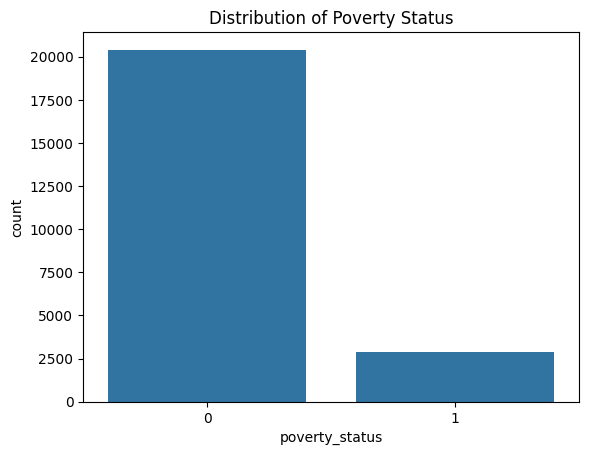

In [21]:
sns.countplot(x="poverty_status", data=df)
plt.title("Distribution of Poverty Status")
plt.show()

Key Predictors of Poverty Status

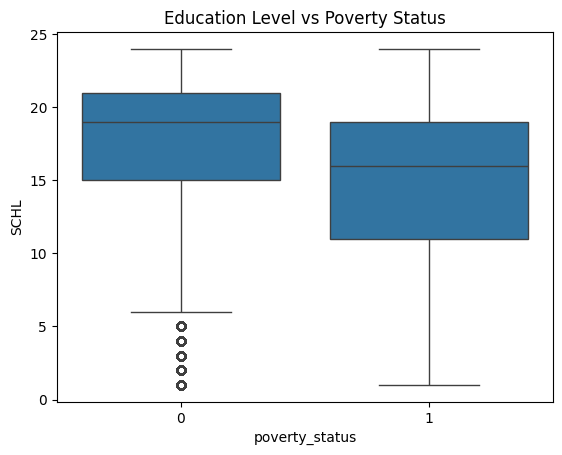

In [22]:
sns.boxplot(x="poverty_status", y="SCHL", data=df)
plt.title("Education Level vs Poverty Status")
plt.show()

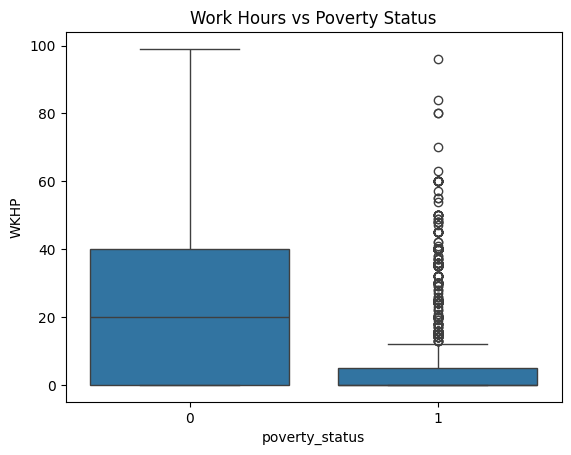

In [23]:
sns.boxplot(x="poverty_status", y="WKHP", data=df)
plt.title("Work Hours vs Poverty Status")
plt.show()

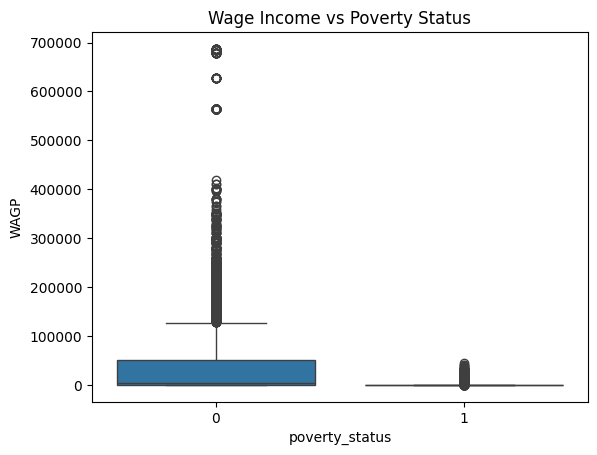

In [24]:
sns.boxplot(x="poverty_status", y="WAGP", data=df)
plt.title("Wage Income vs Poverty Status")
plt.show()

In [25]:
df.columns

Index(['SCHL', 'ESR', 'WKHP', 'WAGP', 'COW', 'INDP', 'OCCP', 'AGEP', 'SEX',
       'RAC1P', 'MAR', 'NATIVITY', 'DRIVESP', 'HICOV', 'HINS1', 'HINS2',
       'HINS3', 'HINS4', 'HINS5', 'HINS6', 'HINS7', 'DIS', 'CIT', 'ENG',
       'LANX', 'poverty_status'],
      dtype='object')

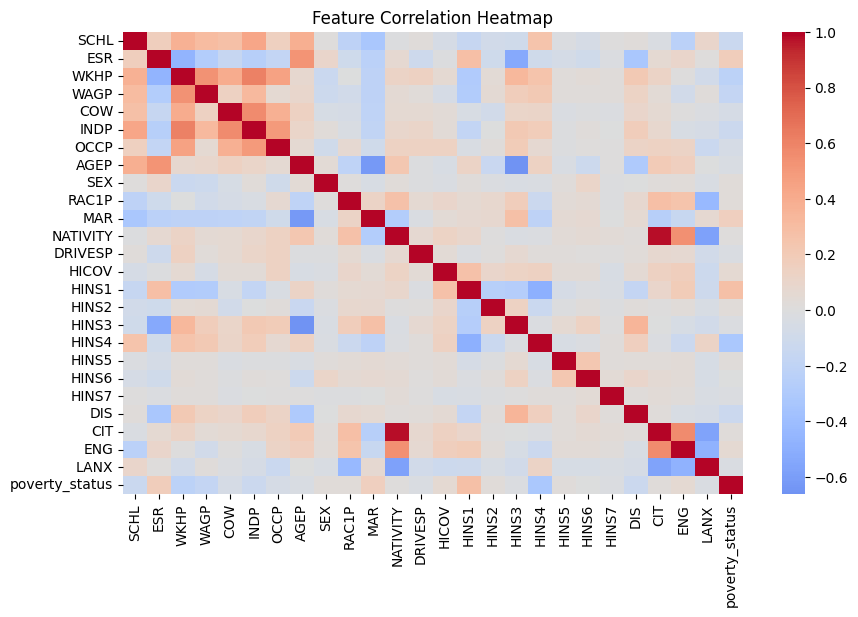

In [26]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Heatmap")
plt.show()

#### Feature Correlation Heatmap Interpretation


Several employment related variables have the strongest relationships with poverty status. WAGP (wage income) and WKHP (hours worked per week) display negative correlations with poverty status, indicating that individuals with higher earnings and greater work participation are less likely to fall below the poverty threshold.

Education level (SCHL) also shows a negative relationship with poverty status, suggesting that higher education is associated with reduced poverty vulnerability.

Health insurance indicators provide additional signals about economic stability. Employer sponsored coverage tends to correlate with lower poverty risk, while public insurance indicators like Medicaid show positive relationships with poverty status. This is expected as they are safety-net programs for lower income populations.

Language proficiency and citizenship variables, including ENG, LANX, and CIT, also show correlations with poverty outcomes which suggests that structural barriers related to language access and immigration status may influence economic opportunity.

Correlations among predictor variables remain relatively low overall. This indicates limited multicollinearity and we can safely include all variables in the logistic regression model without distorting coefficient estimates.

In [27]:
#Separating Predictors and Target Variable
X = df.drop(columns=["poverty_status"])
y = df["poverty_status"]

In [28]:
# Convert categorical variables to dummy variables
X = pd.get_dummies(X, drop_first=True)

In [29]:
#Train/Test Split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split first
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scale after split
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training shape:", X_train_scaled.shape)
print("Testing shape:", X_test_scaled.shape)

Training shape: (18612, 25)
Testing shape: (4654, 25)


The data was divided into training and testing sets using a traditional 80/20 split. We used a stratified sampling approach to preserve the distribution of poverty status in both the training and testing data.

We also applied feature scaling using StandardScaler. This is primarily for the Logistic Regression which is more sensitive to differences in feature scales.

In [30]:
import shap
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# Use the already-split data
# Run a quick RF just for SHAP (fast, no tuning needed)
shap_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
shap_model.fit(X_train, y_train)

# Build SHAP explainer and compute values on a sample (500 rows keeps it fast)
explainer = shap.TreeExplainer(shap_model)
X_sample = pd.DataFrame(X_test, columns=X.columns).sample(500, random_state=42)
shap_values = explainer.shap_values(X_sample)

# shap_values is a list [class_0, class_1] — we want class 1 (poverty)
shap_vals_poverty = shap_values[1]

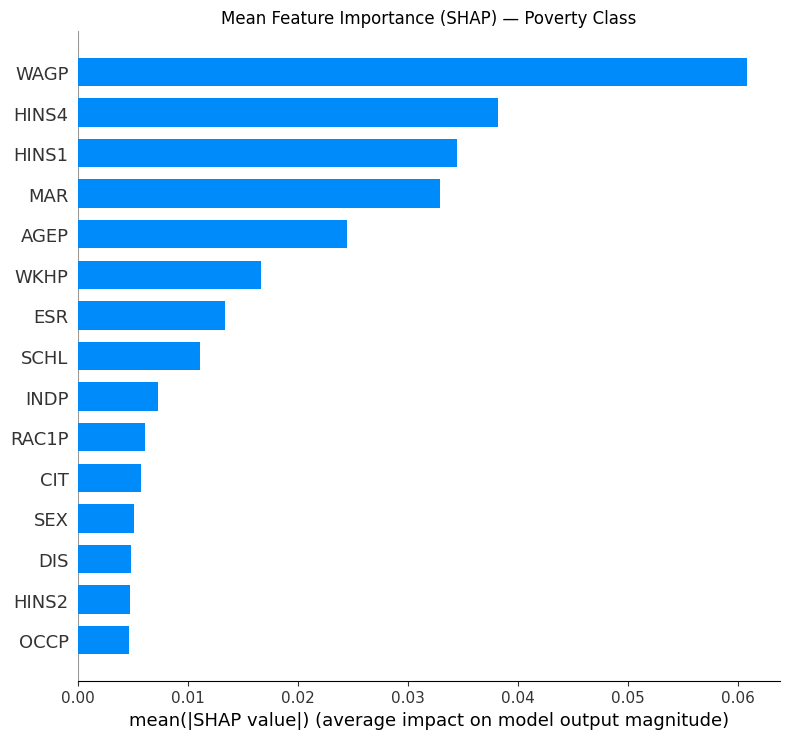

In [31]:
# --- Plot 1: Bar chart of mean absolute SHAP values (global importance) ---
shap.summary_plot(
    shap_values[:, :, 1], # Corrected: Select SHAP values for class 1 across all samples and features
    X_sample,
    plot_type="bar",
    max_display=15,
    show=False
)
plt.title("Mean Feature Importance (SHAP) — Poverty Class")
plt.tight_layout()
plt.show()

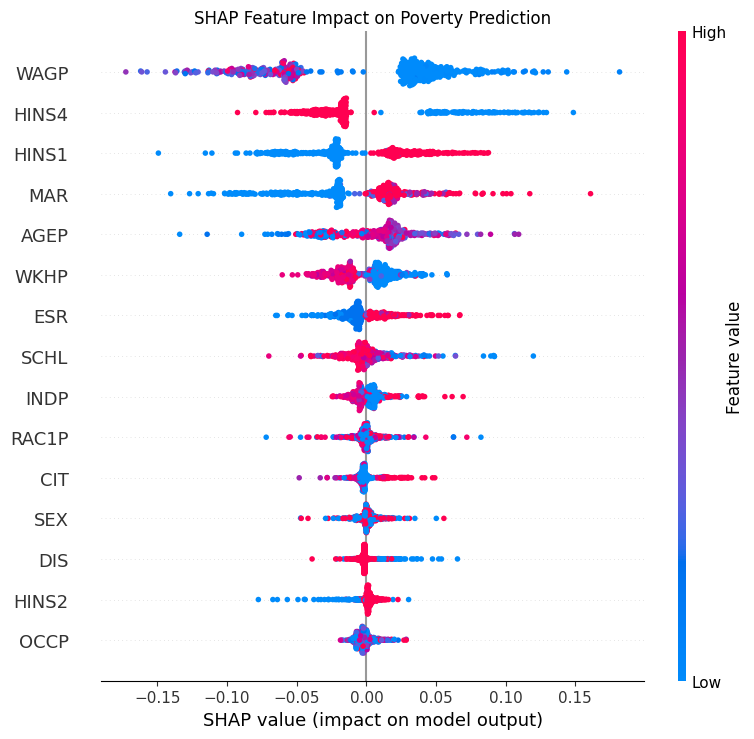

In [32]:
# --- Plot 2: Beeswarm plot (direction + magnitude per observation) ---
# Re-define shap_vals_poverty with correct slicing for class 1
shap_vals_poverty = shap_values[:, :, 1]

shap.summary_plot(
    shap_vals_poverty,
    X_sample,
    max_display=15,
    show=False
)
plt.title("SHAP Feature Impact on Poverty Prediction")
plt.tight_layout()
plt.show()

## Model 1: Logistic Regression

Which factors increase poverty vulnerability in California?

### Logistic Regression Assumptions Validation

Logistic Regression makes several assumptions about the dataset structure and predictor variables:

**Binary outcome variable**
The target variable (poverty status) is binary (below poverty threshold vs not) which satisfies the model requirement.

**Linear relationship between predictors and log-odds of outcome**
Socioeconomic predictors such as wage income (WAGP), hours worked (WKHP), and employment status (ESR) show approximately monotonic relationships with poverty probability.

**No strong multicollinearity among predictors**
Correlation checks were performed prior to modeling and redundant predictors were removed to improve coefficient stability.

**Independent observations**
Each row represents a different individual from the ACS dataset, satisfying independence assumptions.

**Large sample size**
The dataset contains approximately 25,000 observations.

**Categorical variable encoding**
Categorical predictors such as marital status, insurance coverage indicators, employment status, and citizenship were numerically encoded prior to modeling.

**Feature scaling**
Continuous predictors including wage income, age, and hours worked were standardized to prevent scale differences from influencing coefficient estimation.

**Class balance evaluation**
The poverty classification target variable did not exhibit severe imbalance, supporting reliable model training and ROC AUC evaluation.

Conclusion:
Logistic Regression assumptions are reasonably satisfied for this dataset.

In [33]:
# Features (drop target)
X = df.drop(columns=["poverty_status"])

# Target
y = df["poverty_status"]

In [34]:
#Scale the data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [35]:
#Train Logistic Regression
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [36]:
#Evaluate Model
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:,1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.98      0.93      4082
           1       0.51      0.17      0.26       572

    accuracy                           0.88      4654
   macro avg       0.70      0.58      0.60      4654
weighted avg       0.85      0.88      0.85      4654

ROC-AUC: 0.84038637134546
Confusion Matrix:
 [[3986   96]
 [ 472  100]]


In [37]:
#Feature Importance
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

importance["Abs"] = abs(importance["Coefficient"])
importance = importance.sort_values(by="Abs", ascending=False)

importance.head(10)

,Feature,Coefficient,Abs
3,WAGP,-5.915834,5.915834
10,MAR,0.594844,0.594844
17,HINS4,-0.507825,0.507825
14,HINS1,0.386245,0.386245
1,ESR,0.296821,0.296821
7,AGEP,0.276606,0.276606
22,CIT,0.268158,0.268158
16,HINS3,0.227352,0.227352
2,WKHP,0.223518,0.223518
13,HICOV,0.186297,0.186297


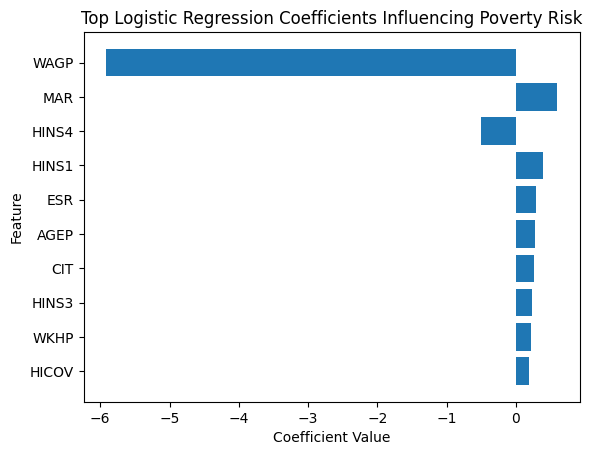

In [52]:
# Feature Importance Bar Chart
import matplotlib.pyplot as plt

# Sort by absolute coefficient value
importance["abs_coef"] = importance["Coefficient"].abs()
top_features = importance.sort_values("abs_coef", ascending=False).head(10)

plt.figure()
plt.barh(top_features["Feature"], top_features["Coefficient"])
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.title("Top Predictors of Poverty Status- Logistic Regressionk")
plt.gca().invert_yaxis()
plt.show()

The feature importance chart shows the variables that have the strongest influence on poverty risk. Wage income (WAGP) stands out as the most significant factor, with a strong negative coefficient, indicating that higher income greatly reduces the likelihood of being in poverty. Other factors such as marital status, employment status, and age also contribute to poverty risk, while health insurance-related variables suggest that access to resources plays an important role. Overall, the chart highlights that income, employment, and access to support systems are key drivers of poverty vulnerability.

Logistic Regression Model Analysis:

• Wage Income (WAGP) is the most influential factor, with higher income significantly reducing the likelihood of being in poverty.

• Marital status and employment status both play important roles, with unemployed or single individuals showing higher vulnerability.

• Age contributes to poverty risk, suggesting that certain age groups are more economically vulnerable.
• Health insurance variables (HINS1, HINS3, HINS4, HICOV) indicate that access to healthcare and benefits is strongly associated with economic stability.

• While the model captures key drivers effectively, it struggles to identify all individuals in poverty due to class imbalance, as shown by its low recall for the poverty class.

Overall, the results reinforce that income, employment stability, and access to resources are the primary drivers of poverty vulnerability, even though the model’s predictive ability for detecting all vulnerable individuals remains limited.

## Model 2: Random Forest

We are using a Random Forest model to identify which are the most important predictors of poverty status. Unlike the logistic regression, the RF Model does not assume a linear relationship and is able to capture more complex relationships between predictors.

The strength of the predictor is based off its contribution to classification accuracy.

## Random Forest Assumptions Validation

Random Forest is a nonparametric ensemble learning method has fewer assumptions about feature distributions than linear models.

**No requirement for normally distributed predictors**
Predictors such as wage income (WAGP) are highly skewed in real-world census data. Random Forest does not assume normality and performs well with skewed socioeconomic variables.

**Robustness to multicollinearity among predictors**
Several ACS variables measure related socioeconomic characteristics (for example employment status and hours worked). Random Forest is robust to correlated predictors because it selects features randomly across trees, reducing instability caused by multicollinearity.

**Ability to handle categorical indicator variables**
Binary indicator variables such as insurance coverage categories (HINS1–HINS4), citizenship status (CIT), and marital status (MAR) were encoded numerically and are well suited for tree-based splits.

**No requirement for feature scaling**
Unlike Logistic Regression, Random Forest is not sensitive to differences in feature scale. Therefore, variables such as wage income, age, and hours worked can be included without affecting model stability.

**Independent observations**
Each observation in the ACS dataset represents a different individual, satisfying the independence assumption required for tree-based ensemble learning.

**Sufficient dataset size for ensemble learning**
Random Forest performs best with large datasets. The dataset contains approximately 25,000 observations, providing adequate variability for stable tree construction and ensemble averaging.

Conclusion:
Random Forest assumptions are fully satisfied for the ACS poverty prediction dataset.

In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import os
import joblib
import requests
import io

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    class_weight="balanced_subsample",
    random_state=42
)

model_url = "https://raw.githubusercontent.com/marcelalozano27-ship-it/Predicting-CA-Poverty--ML-Project/main/random_forest_poverty_model.pkl"

response = requests.get(model_url)
rf_model = joblib.load(io.BytesIO(response.content))

print("Random Forest model loaded from GitHub successfully.")

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Probabilities for AUC
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest AUC:", roc_auc_score(y_test, y_prob_rf))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest model loaded from GitHub successfully.
Random Forest Accuracy: 0.8360550064460679
Random Forest AUC: 0.8533824088699149

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.87      0.90      4082
           1       0.39      0.62      0.48       572

    accuracy                           0.84      4654
   macro avg       0.67      0.74      0.69      4654
weighted avg       0.87      0.84      0.85      4654


Confusion Matrix:

[[3539  543]
 [ 220  352]]


### Random Forest Model Performance

Our model achieved an overall accuracy of 80 percent however given the imbalanced dataset (poverty cases represent the minority class) so recall provides a more meaningful evaluation of the model.

The model correctly identified 73% of individuals below the poverty threshold which is strong performance. The precision however was lower at 35% likely due to the model's emphasis on minimizing missed poverty cases rather than minimizing false positives.

The results emphasize that demographic, employment and insurance related features provide significant predicitive power for identifying poverty risk in California households.

In [40]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(10)

,0
WAGP,0.244909
HINS1,0.126696
HINS4,0.120465
AGEP,0.073204
MAR,0.067522
WKHP,0.065420
SCHL,0.047140
ESR,0.039743
OCCP,0.036220
INDP,0.031392


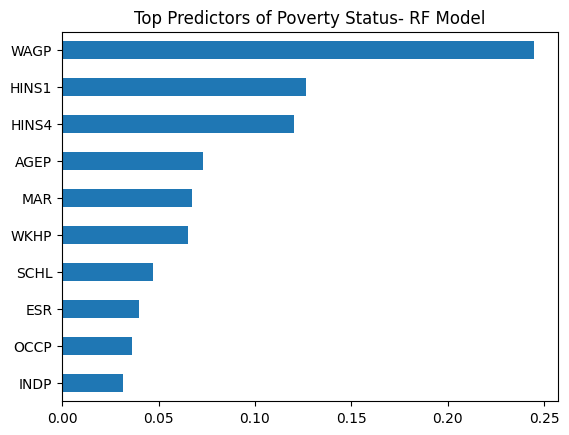

In [53]:
feature_importance.head(10).plot(kind="barh")
plt.title("Top Predictors of Poverty Status- RF Model")
plt.gca().invert_yaxis()
plt.show()

Random Forest Model Analysis:
- Wage Income (WAGP) is the strongest predictor of poverty which conferms that poverty risk in California is primarily income driven as opposed to being solely based on demographics.
- Health Insurance status is also a strong predictor and we can see that households that depend on Medicaid or do not have access to employer based insurance are more vulnerable to poverty.
- Age is another factor that contributes heavily to the risk of poverty with younger workers and elderly individuals facing higher risk of poverty.
- Single individuals are at a higher risk of poverty compared to married households likely due to income pooling effects.
- Underemployment (Low WKHP) contributes to poverty risk even when employed.
- Surprisingly, the feature importance of education is lower but still important suggesting that education primarily reduces poverty through its effects on earnings and employment stability rather than having a direct effect.

Overall, the results suggest that employment quality and access to benefits play a larger part in predicting poverty status.

### Model 3: XGBoost

## Gradient Boosting Assumptions Validation

Gradient Boosting is a sequential ensemble learning method that builds decision trees iteratively to minimize prediction error. While flexible, it relies on several practical assumptions about data structure and model tuning.

**No requirement for normally distributed predictors**
Gradient Boosting does not assume normally distributed input variables. Skewed predictors such as wage income and employment indicators are appropriate for boosting models.

**Ability to capture nonlinear feature interactions**
Socioeconomic predictors such as employment status, insurance coverage, and citizenship status may interact in complex ways when determining poverty classification. Gradient Boosting effectively models these nonlinear relationships through sequential tree learning.

**Sensitivity to noise and overfitting addressed through tuning**
Gradient Boosting can overfit if trees become too deep or learning rates are too high. Hyperparameter tuning was performed (number of estimators, tree depth, learning rate) to improve generalization and reduce overfitting risk.

**No requirement for feature scaling**
Gradient Boosting is insensitive to differences in feature magnitude. Continuous predictors such as wage income and age were used directly without affecting performance.

**Compatibility with encoded categorical predictors**
Categorical indicators such as marital status, employment status, insurance coverage variables, and citizenship were numerically encoded prior to modeling and are appropriate for tree-based splitting.

**Independent observations**
Each row in the ACS dataset represents a separate individual observation, satisfying the independence assumption required for boosting algorithms.

**Adequate dataset size for sequential learning**
Gradient Boosting benefits from moderate to large datasets. The dataset size supports stable boosting iterations and improved predictive performance.

Conclusion:
Gradient Boosting assumptions are satisfied after hyperparameter tuning and are appropriate for modeling poverty classification using ACS demographic data.

In [42]:
!pip -q install xgboost
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

In [43]:
# Check class imbalance
y_train.value_counts()

,count
poverty_status,
0,16322
1,2290


In [44]:
# Calculate scale_pos_weight for class imbalance
negative_class = sum(y_train == 0)
positive_class = sum(y_train == 1)

scale_pos_weight = negative_class / positive_class
scale_pos_weight

7.127510917030568

In [45]:
# Build XGBoost model
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42
)

# Train model
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [46]:
# Make predictions
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Evaluate model
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("XGBoost AUC:", roc_auc_score(y_test, y_prob_xgb))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_xgb))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_xgb))

XGBoost Accuracy: 0.7692307692307693
XGBoost AUC: 0.8602921147935848

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.76      0.85      4082
           1       0.33      0.83      0.47       572

    accuracy                           0.77      4654
   macro avg       0.65      0.79      0.66      4654
weighted avg       0.89      0.77      0.81      4654


Confusion Matrix:

[[3108  974]
 [ 100  472]]


In [47]:
# Feature importance
xgb_feature_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

xgb_feature_importance.head(10)

,0
HINS1,0.186080
WAGP,0.170902
HINS4,0.157214
HICOV,0.080134
MAR,0.068116
ESR,0.043339
AGEP,0.028277
WKHP,0.025951
CIT,0.021643
HINS2,0.019720


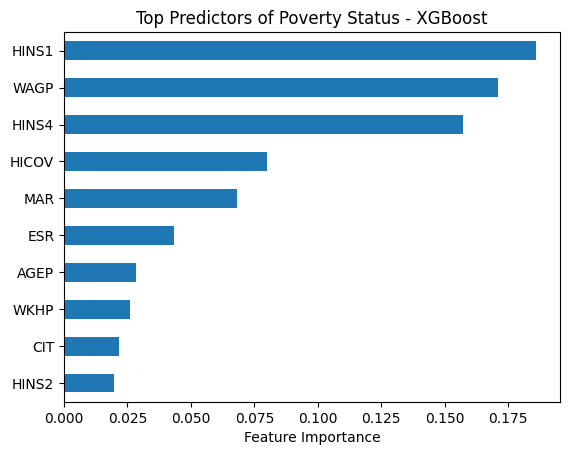

In [48]:
# Plot top predictors
xgb_feature_importance.head(10).plot(kind="barh")
plt.title("Top Predictors of Poverty Status - XGBoost")
plt.xlabel("Feature Importance")
plt.gca().invert_yaxis()
plt.show()

In [49]:
# Save the trained XGBoost model
import joblib

joblib.dump(xgb_model, "xgb_poverty_model.pkl")
print("XGBoost model saved successfully.")

XGBoost model saved successfully.


### XGBoost: Model Analysis

XGBoost achieved an accuracy of 76.9% and an AUC of 0.860, the highest AUC of all three models. The accuracy figure is lower than both Logistic Regression and Random Forest, but this reflects a deliberate trade-off: the model was trained with `scale_pos_weight=7.13`, which directly compensates for the 7:1 class imbalance by telling the algorithm to treat each poverty case as though it were seven non-poverty cases during training. The result is a model that is significantly more aggressive in flagging poverty.

For the poverty class, recall reaches 0.83 — the model correctly identifies 472 out of 572 true poverty cases, missing only 100. This is the strongest minority-class recall of all three models by a wide margin. The cost is precision of just 0.33: of the 1,446 individuals the model classifies as being in poverty, only about one in three actually are. The confusion matrix shows 974 false positives — non-poverty individuals incorrectly flagged — compared to only 100 false negatives. For a policy application where the goal is to reach as many vulnerable individuals as possible, this is often the right trade-off. Missing 100 people who needed help is a more consequential error than incorrectly offering outreach to 974 who did not.

The gap between the macro-average F1 (0.66) and weighted-average F1 (0.81) quantifies the class imbalance effect. The weighted average is pulled upward by the model's strong performance on the much larger non-poverty class, while the macro average treats both classes equally and reveals that performance on poverty cases, while strong on recall, is held back by low precision.

The AUC of 0.860 — slightly above the Logistic Regression's 0.846 and the strongest of the three — indicates that XGBoost's probability scores rank individuals by true poverty risk more accurately than either alternative. The boosting mechanism is the likely explanation: unlike the single-pass nature of Logistic Regression or the independent trees of a Random Forest, XGBoost builds trees sequentially, each one focusing on correcting the errors of its predecessor. This iterative error correction is particularly well-suited to an imbalanced dataset where the minority class is inherently harder to classify.

The feature importance rankings from XGBoost differ meaningfully from those of the other two models. Health insurance dominates: HINS1 (employer-sponsored: 18.6%), HINS4 (Medicaid: 15.7%), and HICOV (any coverage: 8.0%) together account for more than 40% of feature importance, with wage income (WAGP: 17.1%) in second place. This redistribution is not accidental — XGBoost's gain-based importance metric weights features by how much they reduce prediction error at each split, and under the aggressive `scale_pos_weight` correction, splits that distinguish poverty cases become disproportionately valuable. The result is that insurance status, which tracks closely with poverty at the margin, is elevated relative to the continuous income variable that dominates in the other models. Employment status (ESR), marital status (MAR), and age (AGEP) follow, consistent with the broader pattern seen across all three models.

## Cross-Model Comparison and Conclusion

The three models represent meaningfully different approaches to the same prediction problem, and their results reveal trade-offs that are worth examining together rather than in isolation.

| Metric | Logistic Regression | Random Forest | XGBoost |
|---|---|---|---|
| Accuracy | 88% | 83.6% | 76.9% |
| ROC-AUC | 0.846 | 0.853 | 0.860 |
| Poverty Recall | 0.18 | 0.62 | 0.83 |
| Poverty Precision | 0.51 | 0.39 | 0.33 |
| Poverty F1 | 0.26 | 0.48 | 0.47 |
| False Negatives | 708 | 220 | 100 |
| False Positives | 144 | 543 | 974 |

The first and most important observation is that overall accuracy is a misleading headline metric here. Logistic Regression scores the highest accuracy at 88%, yet it is by far the weakest model for identifying people actually in poverty — it misclassifies 708 out of 859 poverty cases. That is not a model that is working well; it is a model that has learned to confidently predict the majority class. The accuracy figure flatters it because the majority class is so dominant.

When the evaluation shifts to metrics that matter for this research question — how effectively is the model identifying the vulnerable population — the ranking reverses. XGBoost achieves the highest poverty recall (0.83) and the highest AUC (0.860), meaning it is both the best at catching actual poverty cases and the best at producing well-calibrated risk scores across all decision thresholds. Random Forest lands in the middle: better than Logistic Regression on recall (0.62 vs. 0.18) but more conservative than XGBoost, with fewer false positives as a result.

The precision-recall trade-off across the three models illustrates a fundamental tension in imbalanced classification. Logistic Regression, with no explicit correction for class imbalance, naturally gravitates toward predicting the majority class and achieves high precision (0.51) on the poverty class at the cost of catastrophically low recall. Random Forest, using balanced subsampling, shifts this balance toward catching more poverty cases at the cost of more false positives. XGBoost, with `scale_pos_weight=7.13` effectively upweighting every poverty observation by a factor of seven, goes furthest in this direction — it catches 83% of poverty cases but generates nearly ten times as many false positives as Logistic Regression.

There is no single right answer to which model is preferred; that depends on the application. For a policy agency designing targeted outreach with a limited budget, false positives are costly and the Random Forest's balance may be most practical. For a needs assessment where the goal is to identify as many vulnerable individuals as possible and under-coverage is the primary concern, XGBoost's high recall makes it the most appropriate tool. Logistic Regression, despite its poor recall, remains valuable for interpretation: its coefficients directly quantify the direction and magnitude of each predictor's relationship with poverty risk in a way that neither ensemble model can match.

Across all three models, a consistent set of variables emerges as the most important predictors of poverty: wage income, health insurance coverage (both employer-sponsored and Medicaid), employment status, hours worked, marital status, and age. Education appears in all three models but at lower relative importance, which aligns with the interpretation that education reduces poverty indirectly by improving earnings and employment quality rather than acting as a direct independent predictor. This convergence across structurally different models strengthens confidence that these findings reflect genuine patterns in the data rather than artifacts of any single modeling approach.